In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Preprocess Telecom DataSet

In [2]:
open_mesh_path = "/content/drive/MyDrive/DataSets/MSResearch/openMesh/"

In [3]:
link_metadata_df = pd.read_csv(open_mesh_path + "links_metadata.csv")
link_rawdata_df = pd.read_csv(open_mesh_path + "links_rawdata.csv")

In [4]:
link_metadata_df.head()

,sublink_id,frequency,length,site_0_lat,site_0_lon,site_1_lat,site_1_lon,rsl,polarization
0,1,62640,623.0,40.729552,-73.945949,40.733910,-73.950594,-60.0,Vertical
1,2,60480,222.1,40.727553,-73.946045,40.729552,-73.945949,-62.0,Vertical
2,3,62640,623.0,40.729552,-73.945949,40.733910,-73.950594,-60.0,Vertical
3,4,58320,451.8,40.736760,-73.954410,40.733902,-73.950604,-57.0,Vertical
4,5,60480,222.1,40.729552,-73.945949,40.727553,-73.946045,-57.0,Vertical


In [49]:
link_metadata_df[['site_0_lat', 'site_0_lon']].describe()

,site_0_lat,site_0_lon
count,103.000000,103.000000
mean,40.698714,-73.966231
std,0.040048,0.029594
min,40.606661,-74.013631
25%,40.672601,-73.989210
50%,40.696038,-73.964204
75%,40.719898,-73.943486
max,40.830386,-73.913606


In [6]:
site0_lat_lon = link_metadata_df[['site_0_lat', 'site_0_lon']].value_counts()

In [48]:
site0_lat_lon

,,count
site_0_lat,site_0_lon,
40.686020,-73.917496,4
40.645933,-74.013631,3
40.657900,-74.004900,3
40.686016,-73.917493,3
40.716098,-73.985997,3
...,...,...
40.725790,-73.983550,1
40.736717,-73.954650,1
40.733902,-73.950604,1


In [25]:
((link_metadata_df['site_0_lat']>40.5) & (link_metadata_df['site_0_lat']<40.9)).sum()

np.int64(103)

In [44]:
((link_metadata_df['site_0_lon']<-73.9) & (link_metadata_df['site_0_lon']>-74.1)).sum()

np.int64(103)

In [47]:
link_metadata_df['site_0_lat'].between(40.5, 40.9, inclusive='both')

,site_0_lat
0,True
1,True
2,True
3,True
4,True
...,...
98,True
99,True
100,True
101,True


In [ ]:
link_metadata_df.describe()

,sublink_id,frequency,length,site_0_lat,site_0_lon,site_1_lat,site_1_lon,rsl
count,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000
mean,52.000000,29880.388350,1653.901942,40.698714,-73.966231,40.701122,-73.961161,-59.902913
std,29.877528,28174.616241,1330.847242,0.040048,0.029594,0.040408,0.028229,7.354490
min,1.000000,5270.000000,24.500000,40.606661,-74.013631,40.601913,-74.013680,-83.000000
25%,26.500000,5560.000000,602.650000,40.672601,-73.989210,40.674937,-73.983635,-64.000000
50%,52.000000,5810.000000,1400.600000,40.696038,-73.964204,40.696096,-73.954687,-59.000000
75%,77.500000,62640.000000,2296.850000,40.719898,-73.943486,40.724676,-73.942992,-56.000000
max,103.000000,69120.000000,6936.500000,40.830386,-73.913606,40.830386,-73.906361,-34.000000


In [ ]:
link_metadata_df['polarization'].value_counts()

,count
polarization,
Vertical,103


In [ ]:
link_metadata_df.isna().sum()

,0
sublink_id,0
frequency,0
length,0
site_0_lat,0
site_0_lon,0
site_1_lat,0
site_1_lon,0
rsl,0
polarization,0


In [ ]:
link_metadata_df.drop(columns=['polarization'], inplace=True)

In [ ]:
link_metadata_df.head()

,sublink_id,frequency,length,site_0_lat,site_0_lon,site_1_lat,site_1_lon,rsl
0,1,62640,623.0,40.729552,-73.945949,40.733910,-73.950594,-60.0
1,2,60480,222.1,40.727553,-73.946045,40.729552,-73.945949,-62.0
2,3,62640,623.0,40.729552,-73.945949,40.733910,-73.950594,-60.0
3,4,58320,451.8,40.736760,-73.954410,40.733902,-73.950604,-57.0
4,5,60480,222.1,40.729552,-73.945949,40.727553,-73.946045,-57.0


In [ ]:
link_metadata_df['frequency'].value_counts()

,count
frequency,
68040,13
5560,8
5490,8
5710,7
64800,7
58320,6
60480,5
24200,4
24100,4


In [10]:
link_metadata_df[link_metadata_df['frequency']==68040]

,sublink_id,frequency,length,site_0_lat,site_0_lon,site_1_lat,site_1_lon,rsl
6,7,68040,3486.6,40.715587,-73.984400,40.727403,-73.946167,-58.0
7,8,68040,2178.1,40.696093,-73.939749,40.686198,-73.917500,-50.0
15,16,68040,631.4,40.672601,-73.964191,40.678131,-73.962457,-52.0
23,24,68040,2791.9,40.715587,-73.984400,40.725693,-73.954143,-55.0
26,27,68040,1355.5,40.672554,-73.964452,40.660742,-73.960408,-64.0
31,32,68040,839.7,40.672599,-73.964204,40.680123,-73.963210,-62.0
35,36,68040,839.7,40.672599,-73.964204,40.680123,-73.963210,-62.0
36,37,68040,4316.1,40.635115,-73.950557,40.672517,-73.964437,-58.0
39,40,68040,1987.9,40.672556,-73.964435,40.655626,-73.956798,-60.0
43,44,68040,101.5,40.672601,-73.964193,40.673511,-73.964084,-60.0


In [ ]:
link_metadata_df.isnull().sum()

,0
sublink_id,0
frequency,0
length,0
site_0_lat,0
site_0_lon,0
site_1_lat,0
site_1_lon,0
rsl,0


In [ ]:
link_metadata_df['sublink_id'].value_counts().sum()

np.int64(103)

In [ ]:
link_rawdata_df.head()

,Datetime,1,2,3,4,5,6,7,8,9,...,94,95,96,97,98,99,100,101,102,103
0,2023-10-29 00:00:00,-65.0,-62.0,-61.0,-54.0,-60.0,-49.0,-58.0,-49.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-10-29 00:01:00,-65.0,-61.0,-61.0,-55.0,-56.0,-49.0,-58.0,-49.0,-83.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-10-29 00:02:00,-65.0,-61.0,-60.0,-55.0,-58.0,-49.0,-58.0,-50.0,-83.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023-10-29 00:03:00,-65.0,-62.0,-61.0,-55.0,-56.0,-51.0,-58.0,-49.0,-83.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2023-10-29 00:04:00,-65.0,-62.0,-62.0,-56.0,-57.0,-50.0,-58.0,-49.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
link_rawdata_df.describe()

,1,2,3,4,5,6,7,9,10,11,...,94,95,96,97,98,99,100,101,102,103
count,264572.000000,268740.000000,266700.000000,266927.000000,262948.000000,273150.000000,270894.000000,273401.000000,274531.000000,242615.000000,...,244041.000000,249043.000000,236440.000000,249066.000000,247938.000000,246934.000000,242609.000000,248995.000000,241532.00000,249768.000000
mean,-65.158909,-61.426970,-60.225726,-57.147789,-58.674217,-51.393271,-57.571563,-75.028654,-57.388896,-63.112689,...,-65.165521,-70.864044,-61.940509,-65.133041,-77.372880,-61.066917,-68.254302,-51.582835,-66.64774,-68.567286
std,1.125132,1.129316,1.226513,1.219119,1.438019,2.194044,2.206118,1.173216,2.184041,1.017742,...,0.771485,0.705488,4.289726,5.721360,0.818289,0.643321,1.545378,0.763567,2.11960,1.007670
min,-72.000000,-72.000000,-71.000000,-72.000000,-70.000000,-71.000000,-80.000000,-96.000000,-72.000000,-75.000000,...,-80.000000,-83.000000,-82.000000,-84.000000,-87.000000,-76.000000,-84.000000,-80.000000,-80.00000,-82.000000
25%,-66.000000,-62.000000,-61.000000,-58.000000,-59.000000,-53.000000,-58.000000,-76.000000,-59.000000,-64.000000,...,-66.000000,-71.000000,-62.000000,-70.000000,-78.000000,-61.000000,-69.000000,-52.000000,-68.00000,-69.000000
50%,-65.000000,-61.000000,-60.000000,-57.000000,-58.000000,-51.000000,-57.000000,-75.000000,-57.000000,-63.000000,...,-65.000000,-71.000000,-61.000000,-65.000000,-77.000000,-61.000000,-68.000000,-52.000000,-66.00000,-68.000000
75%,-64.000000,-61.000000,-59.000000,-56.000000,-58.000000,-50.000000,-56.000000,-74.000000,-56.000000,-62.000000,...,-65.000000,-70.000000,-59.000000,-63.000000,-77.000000,-61.000000,-67.000000,-51.000000,-65.00000,-68.000000
max,-60.000000,-57.000000,-56.000000,-51.000000,-54.000000,-47.000000,-54.000000,-67.000000,-52.000000,-52.000000,...,-60.000000,-68.000000,-56.000000,-51.000000,-69.000000,-55.000000,-61.000000,-45.000000,-58.00000,-65.000000


In [ ]:
link_rawdata_df.isna().sum()

,0
Datetime,0
1,18159
2,13991
3,16031
4,15804
...,...
99,35797
100,40122
101,33736
102,41199


In [ ]:
link_rawdata_df.shape

(282731, 104)

In [ ]:
# Melt the link_rawdata_df to long format
link_rawdata_melted = link_rawdata_df.melt(id_vars=['Datetime'], var_name='sublink_id', value_name='rsl_value')


In [ ]:
link_rawdata_melted.shape

(29121293, 3)

In [ ]:
link_rawdata_melted.head()

,Datetime,sublink_id,rsl_value
0,2023-10-29 00:00:00,1,-65.0
1,2023-10-29 00:01:00,1,-65.0
2,2023-10-29 00:02:00,1,-65.0
3,2023-10-29 00:03:00,1,-65.0
4,2023-10-29 00:04:00,1,-65.0


In [ ]:
link_rawdata_melted['sublink_id'].value_counts()

,count
sublink_id,
1,282731
2,282731
3,282731
4,282731
5,282731
...,...
99,282731
100,282731
101,282731


In [ ]:
link_rawdata_melted.isna().sum()

,0
Datetime,0
sublink_id,0
rsl_value,3360947


In [ ]:
29121293-3360947

25760346

In [ ]:
link_rawdata_melted.isnull().sum()

,0
Datetime,0
sublink_id,0
rsl_value,3360947


In [ ]:
link_rawdata_melted = link_rawdata_melted[~link_rawdata_melted['rsl_value'].isna()]

In [ ]:
link_rawdata_melted.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25760346 entries, 0 to 29121291
Data columns (total 3 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   Datetime    object
 1   sublink_id  object
 2   rsl_value   object
dtypes: object(3)
memory usage: 786.1+ MB


In [ ]:
link_rawdata_melted['sublink_id'] = pd.to_numeric(link_rawdata_melted['sublink_id'])

In [ ]:
# Merge the dataframes
merged_link_df = pd.merge(link_rawdata_melted, link_metadata_df, on='sublink_id', how='left')

In [ ]:
merged_link_df.shape

(25760346, 10)

In [ ]:
merged_link_df.head()

,Datetime,sublink_id,rsl_value,frequency,length,site_0_lat,site_0_lon,site_1_lat,site_1_lon,rsl
0,2023-10-29 00:00:00,1,-65.0,62640,623.0,40.729552,-73.945949,40.73391,-73.950594,-60.0
1,2023-10-29 00:01:00,1,-65.0,62640,623.0,40.729552,-73.945949,40.73391,-73.950594,-60.0
2,2023-10-29 00:02:00,1,-65.0,62640,623.0,40.729552,-73.945949,40.73391,-73.950594,-60.0
3,2023-10-29 00:03:00,1,-65.0,62640,623.0,40.729552,-73.945949,40.73391,-73.950594,-60.0
4,2023-10-29 00:04:00,1,-65.0,62640,623.0,40.729552,-73.945949,40.73391,-73.950594,-60.0


In [ ]:
#Save Merged Dataset to CSV
merged_link_df.to_csv(open_mesh_path+"merged_link_df.csv", index=False)

## Checkpoint Merged Data (Telecom meta-data)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

In [ ]:
open_mesh_path = "/content/drive/MyDrive/DataSets/MSResearch/openMesh/"

In [ ]:
merged_link_df = pd.read_csv(open_mesh_path+"merged_link_df.csv")

/tmp/ipython-input-4006252594.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  merged_link_df = pd.read_csv(open_mesh_path+"merged_link_df.csv")


In [ ]:
merged_link_df.shape

(25760346, 10)

In [ ]:
merged_link_df[merged_link_df['sublink_id']==3]['site_0_lon'].value_counts()

,count
site_0_lon,
-73.945949,266700


In [ ]:
merged_link_df.columns

Index(['Datetime', 'sublink_id', 'rsl_value', 'frequency', 'length',
       'site_0_lat', 'site_0_lon', 'site_1_lat', 'site_1_lon', 'rsl'],
      dtype='object')

In [ ]:
merged_link_df[['site_0_lat', 'site_0_lon']].value_counts()

,,count
site_0_lat,site_0_lon,
40.686020,-73.917496,1094496
40.727553,-73.946045,815080
40.729552,-73.945949,794220
40.645933,-74.013631,744963
40.672685,-73.963860,739950
...,...,...
40.736717,-73.954650,236440
40.675430,-73.980580,231271
40.696040,-73.939790,228460


In [ ]:
merged_link_df[['site_1_lat', 'site_1_lon']].value_counts()

,,count
site_1_lat,site_1_lon,
40.724676,-73.980730,1164844
40.693888,-73.906380,1094496
40.725903,-73.983635,547089
40.725616,-73.947094,546340
40.672546,-73.964447,544088
...,...,...
40.693819,-73.906361,228460
40.675430,-73.980580,221973
40.656600,-73.999300,189819


In [ ]:
merged_link_df[merged_link_df['rsl']==0].shape

(0, 10)

In [ ]:
display(merged_link_df.head())

,Datetime,sublink_id,rsl_value,frequency,length,site_0_lat,site_0_lon,site_1_lat,site_1_lon,rsl
0,2023-10-29 00:00:00,1,-65.0,62640,623.0,40.729552,-73.945949,40.73391,-73.950594,-60.0
1,2023-10-29 00:01:00,1,-65.0,62640,623.0,40.729552,-73.945949,40.73391,-73.950594,-60.0
2,2023-10-29 00:02:00,1,-65.0,62640,623.0,40.729552,-73.945949,40.73391,-73.950594,-60.0
3,2023-10-29 00:03:00,1,-65.0,62640,623.0,40.729552,-73.945949,40.73391,-73.950594,-60.0
4,2023-10-29 00:04:00,1,-65.0,62640,623.0,40.729552,-73.945949,40.73391,-73.950594,-60.0


In [ ]:
merged_link_df.head()

,Datetime,sublink_id,rsl_value,frequency,length,site_0_lat,site_0_lon,site_1_lat,site_1_lon,rsl
0,2023-10-29 00:00:00,1,-65.0,62640,623.0,40.729552,-73.945949,40.73391,-73.950594,-60.0
1,2023-10-29 00:01:00,1,-65.0,62640,623.0,40.729552,-73.945949,40.73391,-73.950594,-60.0
2,2023-10-29 00:02:00,1,-65.0,62640,623.0,40.729552,-73.945949,40.73391,-73.950594,-60.0
3,2023-10-29 00:03:00,1,-65.0,62640,623.0,40.729552,-73.945949,40.73391,-73.950594,-60.0
4,2023-10-29 00:04:00,1,-65.0,62640,623.0,40.729552,-73.945949,40.73391,-73.950594,-60.0


In [ ]:
# Convert rsl_value to numeric, coercing errors
merged_link_df['rsl_value'] = pd.to_numeric(merged_link_df['rsl_value'], errors='coerce')

plt.figure(figsize=(12, 6))
sns.scatterplot(data=merged_link_df, x='frequency', y='rsl', label='rsl', alpha=0.5)
sns.scatterplot(data=merged_link_df, x='frequency', y='rsl_value', label='rsl_value', alpha=0.5)
plt.xlabel('Frequency')
plt.ylabel('RSL Values')
plt.title('RSL and RSL_Value vs. Frequency')
plt.grid(True)
plt.legend()
plt.show()

ValueError: Unable to parse string "-" at position 2147357

## Checkpoint Merged Data (Telecom meta-data)

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
open_mesh_path = "/content/drive/MyDrive/DataSets/MSResearch/openMesh/"

In [4]:
merged_link_df = pd.read_csv(open_mesh_path+"merged_link_df.csv")

/tmp/ipython-input-4006252594.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  merged_link_df = pd.read_csv(open_mesh_path+"merged_link_df.csv")


In [5]:
merged_link_df.shape

(25760346, 10)

In [8]:
merged_link_df['frequency'].unique()

array([62640, 60480, 58320, 68040, 64800,  5310,  5505,  5825, 65880,
       24100,  5760,  5795,  5560, 24200,  5300,  5270, 69120,  5770,
        5750,  5495,  5710,  5280,  5550,  5570,  5490,  5815,  5500,
        5810,  5510,  5740,  5700])

In [15]:
merged_link_df[merged_link_df['frequency']==60480]['sublink_id'].value_counts()

,count
sublink_id,
18,275171
2,268740
59,266540
5,262948
58,125648


In [17]:
merged_link_df.columns

Index(['Datetime', 'sublink_id', 'rsl_value', 'frequency', 'length',
       'site_0_lat', 'site_0_lon', 'site_1_lat', 'site_1_lon', 'rsl'],
      dtype='object')

In [16]:
# Filter the dataframe for frequency ==
freq_list = [62640, 60480, 58320, 68040, 64800,  5310,  5505,  5825, 65880,
              24100,  5760,  5795,  5560, 24200,  5300,  5270, 69120,  5770,
              5750,  5495,  5710,  5280,  5550,  5570,  5490,  5815,  5500,
              5810,  5510,  5740,  5700]
for frequency in freq_list:
    filtered_df = merged_link_df[merged_link_df['frequency'] == frequency].copy()

    # Convert 'rsl_value' to numeric, coercing errors
    filtered_df['rsl_value'] = pd.to_numeric(filtered_df['rsl_value'], errors='coerce')

    # Convert 'Datetime' to datetime objects
    filtered_df['Datetime'] = pd.to_datetime(filtered_df['Datetime'])

    # Create the scatter plot
    plt.figure(figsize=(6, 2))
    sns.scatterplot(data=filtered_df, x='Datetime', y='rsl_value', alpha=0.5)
    plt.xlabel('Datetime')
    plt.ylabel('RSL Value')
    plt.title('RSL Value vs. Datetime for Frequency '+str(frequency))
    plt.grid(True)
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
merged_link_df.columns

Index(['Datetime', 'sublink_id', 'rsl_value', 'frequency', 'length',
       'site_0_lat', 'site_0_lon', 'site_1_lat', 'site_1_lon', 'rsl'],
      dtype='object')

In [ ]:
merged_link_df[['site_0_lat', 'site_0_lon']].value_counts()

,,count
site_0_lat,site_0_lon,
40.686020,-73.917496,1094496
40.727553,-73.946045,815080
40.729552,-73.945949,794220
40.645933,-74.013631,744963
40.672685,-73.963860,739950
...,...,...
40.736717,-73.954650,236440
40.675430,-73.980580,231271
40.696040,-73.939790,228460


In [ ]:
merged_link_df[['site_1_lat', 'site_1_lon']].value_counts()

,,count
site_1_lat,site_1_lon,
40.724676,-73.980730,1164844
40.693888,-73.906380,1094496
40.725903,-73.983635,547089
40.725616,-73.947094,546340
40.672546,-73.964447,544088
...,...,...
40.693819,-73.906361,228460
40.675430,-73.980580,221973
40.656600,-73.999300,189819


In [ ]:
merged_link_df[merged_link_df['rsl']==0].shape

(0, 10)

In [ ]:
display(merged_link_df.head())

,Datetime,sublink_id,rsl_value,frequency,length,site_0_lat,site_0_lon,site_1_lat,site_1_lon,rsl
0,2023-10-29 00:00:00,1,-65.0,62640,623.0,40.729552,-73.945949,40.73391,-73.950594,-60.0
1,2023-10-29 00:01:00,1,-65.0,62640,623.0,40.729552,-73.945949,40.73391,-73.950594,-60.0
2,2023-10-29 00:02:00,1,-65.0,62640,623.0,40.729552,-73.945949,40.73391,-73.950594,-60.0
3,2023-10-29 00:03:00,1,-65.0,62640,623.0,40.729552,-73.945949,40.73391,-73.950594,-60.0
4,2023-10-29 00:04:00,1,-65.0,62640,623.0,40.729552,-73.945949,40.73391,-73.950594,-60.0


In [ ]:
merged_link_df.head()

,Datetime,sublink_id,rsl_value,frequency,length,site_0_lat,site_0_lon,site_1_lat,site_1_lon,rsl
0,2023-10-29 00:00:00,1,-65.0,62640,623.0,40.729552,-73.945949,40.73391,-73.950594,-60.0
1,2023-10-29 00:01:00,1,-65.0,62640,623.0,40.729552,-73.945949,40.73391,-73.950594,-60.0
2,2023-10-29 00:02:00,1,-65.0,62640,623.0,40.729552,-73.945949,40.73391,-73.950594,-60.0
3,2023-10-29 00:03:00,1,-65.0,62640,623.0,40.729552,-73.945949,40.73391,-73.950594,-60.0
4,2023-10-29 00:04:00,1,-65.0,62640,623.0,40.729552,-73.945949,40.73391,-73.950594,-60.0


In [ ]:
merged_link_df[merged_link_df['sublink_id']==1]['Datetime']

,Datetime
0,2023-10-29 00:00:00
1,2023-10-29 00:01:00
2,2023-10-29 00:02:00
3,2023-10-29 00:03:00
4,2023-10-29 00:04:00
...,...
264567,2024-05-12 08:06:00
264568,2024-05-12 08:07:00
264569,2024-05-12 08:08:00
264570,2024-05-12 08:09:00


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
merged_link_df['sublink_id'].min(), merged_link_df['sublink_id'].max()

(1, 103)

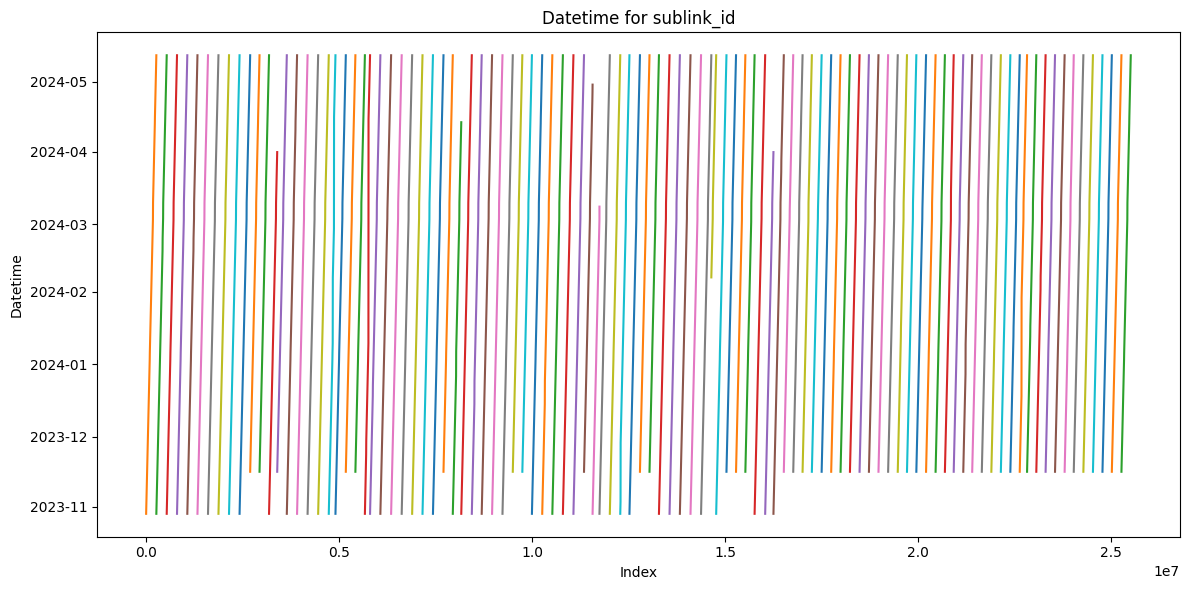

In [ ]:
# Filter for sublink_id = 1
sublink_x_df = [i for i in range(merged_link_df['sublink_id'].max())]
for i in range(merged_link_df['sublink_id'].max()):
    sublink_x_df[i] = merged_link_df[merged_link_df['sublink_id'] == i].copy()
    # Convert 'Datetime' to datetime objects
    sublink_x_df[i]['Datetime'] = pd.to_datetime(sublink_x_df[i]['Datetime'])

# Plot the Datetime column
plt.figure(figsize=(12, 6))
for i in range(len(sublink_x_df)):
  plt.plot(sublink_x_df[i]['Datetime'])
plt.title('Datetime for sublink_id')
plt.xlabel('Index')
plt.ylabel('Datetime')
plt.tight_layout()
plt.show()

In [ ]:
merged_link_df['length'].unique()

array([ 623. ,  222.1,  451.8,  232.6, 3486.6, 2178.1, 1283.1, 2209. ,
       2882.7, 1808.9, 3401.3, 2171.1,  631.4, 1400.6, 1051.4, 3489.4,
        373.3, 2937.8, 2790.5, 2791.9, 1397.8,  690.7, 1355.5, 2938.6,
       1480.4,  839.7,  482.8, 3768.2, 4316.1, 1535.8, 1987.9,  101.5,
       2834.5, 2181.4, 2183. , 6936.5, 2392.7,  865.6, 2939.9, 6928.7,
        813.2, 1834.8, 1845.1, 2373.7,  570.4, 1147.5, 2216.4, 1447.5,
        582.3,  784.2,  809.1, 2220. , 1530.5,   24.5,  268.4,  552.3,
        307.7, 1503.4,  218.6, 1614.8, 2836.2,  771.8, 2859.2,  149. ,
       1673.2,  696.7,  495.1, 1013.6, 3209.6, 3292.4, 1888.7,  352.4,
       1492.7, 3015.2,  571.5,  275.5,  122.4, 4505.6])

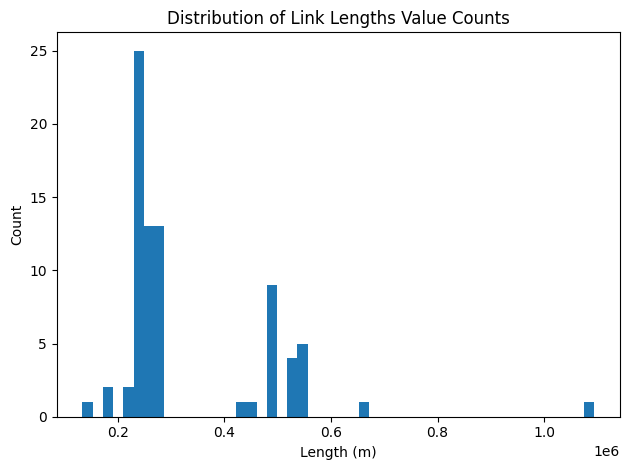

In [ ]:
plt.figure()
plt.hist(merged_link_df['length'].value_counts(), bins=50)
plt.title("Distribution of Link Lengths Value Counts")
plt.xlabel("Length (m)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

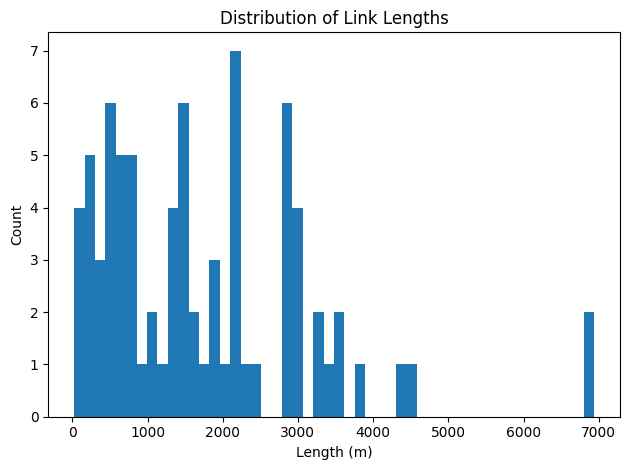

In [ ]:
plt.figure()
plt.hist(merged_link_df['length'].unique(), bins=50)
plt.title("Distribution of Link Lengths")
plt.xlabel("Length (m)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

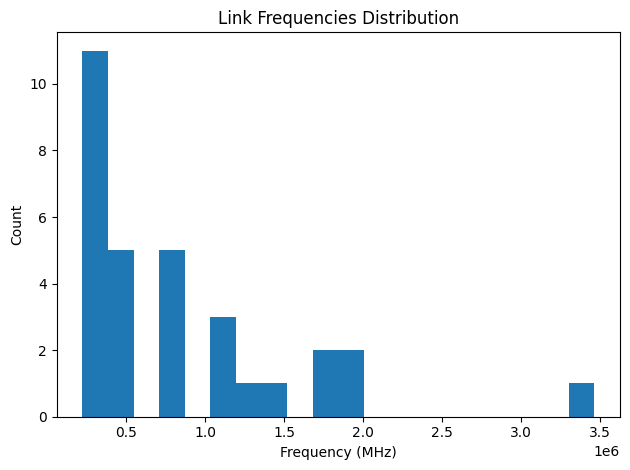

In [ ]:
plt.figure()
plt.hist(merged_link_df['frequency'].value_counts(), bins=20)
plt.title("Link Frequencies Distribution")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
list(merged_link_df[['site_0_lat', 'site_0_lon']].value_counts().index)[0]

(40.68602, -73.917496)

In [ ]:
merged_link_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25760346 entries, 0 to 25760345
Data columns (total 10 columns):
 #   Column      Dtype  
---  ------      -----  
 0   Datetime    object 
 1   sublink_id  int64  
 2   rsl_value   object 
 3   frequency   int64  
 4   length      float64
 5   site_0_lat  float64
 6   site_0_lon  float64
 7   site_1_lat  float64
 8   site_1_lon  float64
 9   rsl         float64
dtypes: float64(6), int64(2), object(2)
memory usage: 1.9+ GB


In [ ]:
unique_site_0 = merged_link_df[['site_0_lat', 'site_0_lon']].drop_duplicates()
unique_site_1 = merged_link_df[['site_1_lat', 'site_1_lon']].drop_duplicates()

In [ ]:
len(unique_site_0), len(unique_site_1)

(68, 78)

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(lons0, lats0, s=10, label="Site 0")
plt.scatter(lons1, lats1, s=10, label="Site 1")
for i in range(len(lats0)):
    plt.plot([lons0[i], lons1[i]], [lats0[i], lats1[i]], color="gray", alpha=0.3)
plt.legend()
plt.title("NYC Mesh Link Topology")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

In [ ]:
merged_link_df.shape

(25760346, 10)